# Read in FY2025

Import your packages

In [5]:
import Pkg
# This installs only the modern, compatible versions
Pkg.add(["DataFrames", "CSV", "InlineStrings", "Plots",
"Colors","StatsPlots", "Statistics", "XLSX", "Dates", "StatsBase", 
"CategoricalArrays", "Missings", "Chain", "FreqTables", "Glob", "MLJ",
"DecisionTree", "XGBoost", "LoggingExtras", "IJulia", "Parquet2"])


   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


Functions

Read in your file

In [6]:
using Parquet2
using DataFrames
filename = "../data/2_ready_for_EDA/raw_fy2017_2025/combined_spending_2017_2025.parquet"
# Load the parquet file
ds = Parquet2.Dataset(filename)
# Convert it to a DataFrame
df = DataFrame(ds)



Row,parent_award_agency_id,award_amount,action_date,period_of_performance_start_date,awarding_sub_agency_name,recipient_uei,primary_place_of_performance_zip_5,type_of_contract_pricing,contract_description,product_or_service_code,naics_code,extent_competed,fiscal_year
,String?,Float64?,DateTime?,DateTime?,String?,String?,String?,String?,String?,String?,String?,String?,Int64?
1,missing,0.0,2017-03-16T00:00:00,2017-03-17T00:00:00,Department of the Air Force,EZZLZJRCKRC3,92128,COST PLUS AWARD FEE,"GLOBAL HAWK, ACAT ID, MXGUI CDRL UPDATE",1510,336411,NOT COMPETED,2017
2,missing,656106.0,2017-07-28T00:00:00,2017-07-28T00:00:00,Department of the Air Force,LHJPD6T16EV9,80916,COST PLUS INCENTIVE FEE,GROUND BASED ELECTRO OPTICAL DEEP SPACE SURVEILLANCE RAPID DEPLOYMENT PROCESS 5.0 PROJECT,J058,334511,FULL AND OPEN COMPETITION,2017
3,missing,2.61431e5,2017-08-31T00:00:00,2017-08-31T00:00:00,Department of the Air Force,CHM5ZAJTSS99,31088,FIRM FIXED PRICE,RADAR WARNING RECEIVER,5895,334511,NOT AVAILABLE FOR COMPETITION,2017
4,missing,301064.0,2016-10-14T00:00:00,2016-10-14T00:00:00,Department of the Air Force,LX3BSV6NNW58,99704,FIRM FIXED PRICE,"OPERATIONS, MAINTENANCE, AND SUPPORT OF THE SOLID STATE PHASED ARRAY SYSTEM (SSPARS).",M123,517910,FULL AND OPEN COMPETITION,2017
5,missing,1.12128e7,2016-12-27T00:00:00,2018-03-31T00:00:00,Department of the Air Force,LFMMBZEMM2X3,32548,COST NO FEE,IGF::CT::IGF EGLIN OPERATION&MAINTENANCE SERVICES INCREMENTAL FUNDING,H210,541330,FULL AND OPEN COMPETITION,2017
6,missing,19200.0,2017-09-19T00:00:00,2017-09-19T00:00:00,Department of the Air Force,HHLEM3ZJKLS6,27526,FIRM FIXED PRICE,IGF::OT::IGF FLAG FOOTBALL OFFICIATING,G003,813990,COMPETED UNDER SAP,2017
7,missing,0.0,2017-07-21T00:00:00,2017-09-01T00:00:00,Department of the Air Force,LX3BSV6NNW58,99704,FIRM FIXED PRICE,"OPERATIONS, MAINTENANCE, AND SUPPORT OF THE SOLID STATE PHASED ARRAY SYSTEM (SSPARS).",M123,517910,FULL AND OPEN COMPETITION,2017
8,missing,4.25439e6,2016-10-24T00:00:00,2016-10-24T00:00:00,Department of the Air Force,LLK6MNEEK7A8,32542,FIRM FIXED PRICE,IGF::OT::IGF WATER STORAGE TANK SUSTAINMENT,J099,237110,FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES,2017
9,missing,-5360.0,2017-09-03T00:00:00,2017-09-03T00:00:00,Department of the Air Force,P8LRGPRLHLQ5,32542,FIRM FIXED PRICE,"YTZP(H), DISC, 55-10 2.15"" OD X 0.40"" TK",6635,327110,COMPETED UNDER SAP,2017


Create data dictionary for coded columns

In [99]:
stats_df = describe(df, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)
CSV.write("stats-rawFY2017-2025.csv", stats_df, transform=(col, val) -> something(val, missing)) 

"stats-rawFY2017-2025.csv"

In [8]:
shape = size(df)
println("The dataset has $(shape[1]) rows and $(shape[2]) columns.")

The dataset has 973394 rows and 13 columns.


# DATA PREPARATION

## Select desireable columns 
keep:
parent_award_agency_id
action_date
award_amount
period_of_performance_start_date
awarding_sub_agency_name
recipient_uei
primary_place_of_performance_zip_5
type_of_contract_pricing
contract_description
product_or_service_code
naics_code
extent_competed
fiscal_year



In [ ]:
# Count where the column :my_column is exactly 0
zero_count = count(==(0), df.award_amount)

308079

In [138]:
# Check zero and negative award amounts
zeros = filter(row -> row.award_amount == 0, df)

println("=== Zero Award Rows by type_of_contract_pricing ===")
println(combine(groupby(zeros, :type_of_contract_pricing), nrow => :count) |> 
    x -> sort(x, :count, rev=true))

println("\n=== Zero Award Rows by extent_competed ===")
println(combine(groupby(zeros, :extent_competed), nrow => :count) |> 
    x -> sort(x, :count, rev=true))

println("\n=== Top 20 PSC codes in zero-award rows ===")
println(first(sort(combine(groupby(zeros, :product_or_service_code), nrow => :count), 
    :count, rev=true), 20))

# Distribution summary
println("\n=== award_amount distribution ===")
println(describe(df[!, [:award_amount]]))

println("\nNegative rows: $(sum(df.award_amount .< 0))")

# Clean: remove zero and negative
df_clean = filter(row -> row.award_amount > 0, df)

println("\nRemoved $(nrow(df) - nrow(df_clean)) rows ($(round((1 - nrow(df_clean)/nrow(df))*100, digits=1))%)")
println("Remaining rows: $(nrow(df_clean))")

=== Zero Award Rows by type_of_contract_pricing ===
15×2 DataFrame
 Row │ type_of_contract_pricing           count  
     │ Union{Missing, String}             Int64  
─────┼───────────────────────────────────────────
   1 │ FIRM FIXED PRICE                   211624
   2 │ COST PLUS FIXED FEE                 50994
   3 │ ORDER DEPENDENT (IDV ALLOWS PRIC…   24156
   4 │ COST NO FEE                          8029
   5 │ COST PLUS INCENTIVE FEE              3845
   6 │ FIXED PRICE INCENTIVE                3795
   7 │ TIME AND MATERIALS                   1667
   8 │ COST PLUS AWARD FEE                  1259
   9 │ FIXED PRICE LEVEL OF EFFORT           943
  10 │ LABOR HOURS                           663
  11 │ FIXED PRICE WITH ECONOMIC PRICE …     633
  12 │ FIXED PRICE AWARD FEE                 206
  13 │ COST SHARING                          181
  14 │ FIXED PRICE REDETERMINATION            45
  15 │ OTHER (APPLIES TO AWARDS WHERE N…      39

=== Zero Award Rows by extent_competed ===
7×2 

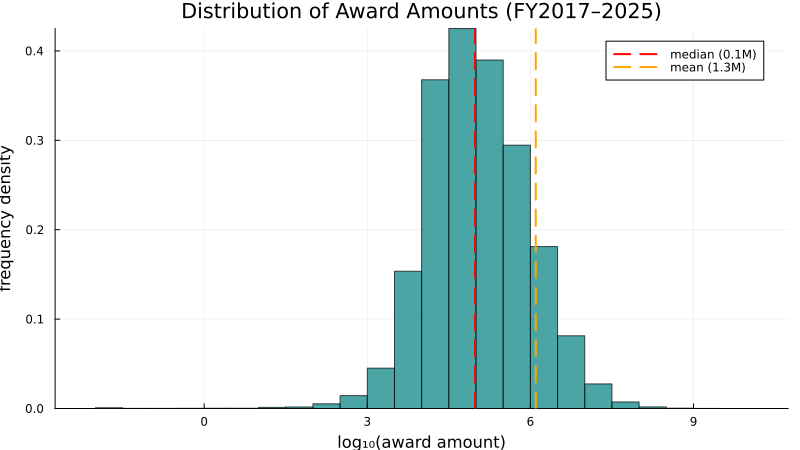

In [139]:
using DataFrames, StatsPlots, Statistics

non_zero = filter(row -> row.award_amount > 0, df_clean).award_amount
log_amounts = log10.(non_zero)

histogram(log_amounts,
    normalize = :pdf,
    bins = 50,
    xlabel = "log₁₀(award amount)",
    ylabel = "frequency density",
    title = "Distribution of Award Amounts (FY2017–2025)",
    label = false,
    color = :teal,
    alpha = 0.7,
    size = (800, 450)
)

# Add median and mean lines
vline!([log10(median(non_zero))], label = "median ($(round(median(non_zero)/1e6, digits=1))M)", color = :red, linestyle = :dash, linewidth = 2)
vline!([log10(mean(non_zero))], label = "mean ($(round(mean(non_zero)/1e6, digits=1))M)", color = :orange, linestyle = :dash, linewidth = 2)

In [142]:
stats_df = describe(df_clean, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)
vscodedisplay(stats_df)
#CSV.write("stats-FY2017-2025.csv", stats_df, transform=(col, val) -> something(val, missing), ) 

## Fix missing values
1. Drop the 19 naics_code rows
2. Create missing as additional parent award agency column
3. Sentinel-fill primary_place_of_performance_zip_5
4. Fill missing contract_description with missing


In [140]:
# 1. Drop the 19 naics_code missing rows
df_clean = dropmissing(df_clean, [:naics_code, :period_of_performance_start_date])
#df_clean = dropmissing(df_clean, :naics_code)


# 2. parent_award_agency_id — fill missing with sentinel, add binary flag
df_clean.parent_award_agency_id = coalesce.(df_clean.parent_award_agency_id, "MISSING_AGENCY_ID")

# 3. primary_place_of_performance_zip_5 — fill with sentinel
df_clean.primary_place_of_performance_zip_5 = coalesce.(df_clean.primary_place_of_performance_zip_5, "00000")

# 4. contract_description — fill with empty string
df_clean.contract_description = coalesce.(df_clean.contract_description, "")

# 5. Remove awarding_sub_agency_name (too many missings)
select!(df_clean, Not(:awarding_sub_agency_name))

# Verify no remaining missings
println(describe(df_clean, :nmissing))

12×2 DataFrame
 Row │ variable                           nmissing 
     │ Symbol                             Int64    
─────┼─────────────────────────────────────────────
   1 │ parent_award_agency_id                    0
   2 │ award_amount                              0
   3 │ action_date                               0
   4 │ period_of_performance_start_date          0
   5 │ recipient_uei                             0
   6 │ primary_place_of_performance_zip…         0
   7 │ type_of_contract_pricing                  0
   8 │ contract_description                      0
   9 │ product_or_service_code                   0
  10 │ naics_code                                0
  11 │ extent_competed                           0
  12 │ fiscal_year                               0


In [141]:
vscodedisplay(df_clean)

## Add duration columns and remove date columns

In [144]:
using Dates
df1 = copy(df_clean)

# Create action_to_start_days
df1.action_to_start_days = Dates.value.(
    df1.period_of_performance_start_date .- df1.action_date
)

# Extract start year
df1.performance_start_year = Dates.year.(df1.period_of_performance_start_date)

# Drop period_of_performance_start_date, action_date, and fiscal_year
select!(df1, Not([:period_of_performance_start_date, :action_date, :fiscal_year]))

vscodedisplay(df1)

In [149]:
# Numeric columns
df1.award_amount = Float64.(df1.award_amount)

# String columns
df1.recipient_uei = String.(df1.recipient_uei)
df1.type_of_contract_pricing = String.(df1.type_of_contract_pricing)
df1.product_or_service_code = String.(df1.product_or_service_code)
df1.extent_competed = String.(df1.extent_competed)

593165-element Vector{String}:
 "FULL AND OPEN COMPETITION"
 "NOT AVAILABLE FOR COMPETITION"
 "FULL AND OPEN COMPETITION"
 "FULL AND OPEN COMPETITION"
 "COMPETED UNDER SAP"
 "FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES"
 "NOT COMPETED"
 "FULL AND OPEN COMPETITION"
 "FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES"
 "COMPETED UNDER SAP"
 ⋮
 "NOT COMPETED"
 "NOT AVAILABLE FOR COMPETITION"
 "FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES"
 "COMPETED UNDER SAP"
 "NOT COMPETED"
 "FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES"
 "FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES"
 "FULL AND OPEN COMPETITION"
 "FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES"

In [150]:
zero_days = filter(row -> row.action_to_start_days == 0, df1)

println("Count: $(nrow(zero_days))")
println("Award amount stats for zero-day rows:")
println(describe(zero_days[!, [:award_amount]]))

# Compare to overall
println("\nOverall award amount stats:")
println(describe(df1[!, [:award_amount]]))

Count: 294105
Award amount stats for zero-day rows:
1×7 DataFrame
 Row │ variable      mean       min      median   max        nmissing  eltype   
     │ Symbol        Float64    Float64  Float64  Float64    Int64     DataType 
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ award_amount  9.11255e5     0.01  63051.3  3.87983e9         0  Float64

Overall award amount stats:
1×7 DataFrame
 Row │ variable      mean       min      median   max        nmissing  eltype   
     │ Symbol        Float64    Float64  Float64  Float64    Int64     DataType 
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ award_amount  1.25501e6     0.01  95780.0  3.87983e9         0  Float64


In [151]:
stats_df = describe(df1, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)


Row,variable,eltype,nmissing,nunique,min,max,median,mean,std
,Symbol,DataType,Int64,Union…,Any,Any,Union…,Union…,Union…
1,parent_award_agency_id,String,0,23,0300,MISSING_AGENCY_ID,,,
2,award_amount,Float64,0,,0.01,3.87983e9,95780.0,1.25501e6,1.62915e7
3,recipient_uei,String,0,31985,C113QWMDV467,ZZYLVTN9ZCQ8,,,
4,primary_place_of_performance_zip_5,String,0,7544,-,QAT,,,
5,type_of_contract_pricing,String,0,13,COST NO FEE,TIME AND MATERIALS,,,
6,contract_description,String,0,352606,,_,,,
7,product_or_service_code,String,0,1920,1005,Z300,,,
8,naics_code,String,0,888,111110,928110,,,
9,extent_competed,String,0,6,COMPETED UNDER SAP,NOT COMPETED UNDER SAP,,,


literally changed nothing but running it again and again fixed it.... what are you supposed to do with that.

## Roll Up NAICS Code

In [154]:
# 1. Group and Count
value_counts = combine(groupby(df1, :naics_code), nrow => :count)

# 2. Sort by count (descending to see the "biggest" offices first)
sort!(value_counts, :count, rev=true);


# Assuming your column is :naics_code and it might be stored as an Integer or String.
# We convert to string first to ensure we can use 'first' reliably.
naics_str = string.(df1.naics_code)

summary = DataFrame(
    Digits = [2, 3, 4, 5],
    Unique_Count = [
        length(unique(first.(naics_str, 2))),
        length(unique(first.(naics_str, 3))),
        length(unique(first.(naics_str, 4))),
        length(unique(first.(naics_str, 5)))
    ]
)

println(summary)

4×2 DataFrame
 Row │ Digits  Unique_Count 
     │ Int64   Int64        
─────┼──────────────────────
   1 │      2            24
   2 │      3            99
   3 │      4           286
   4 │      5           585


Going to choose 2 digit to capture sector (i have definitions for these)

In [156]:
# Use the '!' symbol to update the column directly in your dataframe
df2 = copy(df1)

df2[!, :naics_code] = passmissing(first).(df2[!, :naics_code], 2)
value_counts = combine(groupby(df2, :naics_code), nrow => :count)
sort!(value_counts, :count, rev=true)
rename!(df2, :naics_code => :naics_code_sector);

## Roll up product or service code
1) product or service cod
2) contract pricing code
3) set aside code
4) parent_award_id


In [38]:
using CSV
using DataFrames
using Glob

function apply_mappers_optimized!(df::DataFrame, mapper_folder::String)
    mapper_files = glob("*.csv", mapper_folder)
    
    for file in mapper_files
        # Use 'stringtype=String' to ensure consistency
        mapping_df = CSV.read(file, DataFrame, stringtype=String)
        
        old_col_name = names(mapping_df)[1]
        new_col_name = names(mapping_df)[2]
        
        # Safety Sync: Force both 'key' columns to String and strip whitespace
        # This prevents the "300" (Int) vs "300" (String) mismatch
        df[!, Symbol(old_col_name)] = [ismissing(x) ? missing : strip(string(x)) for x in df[!, Symbol(old_col_name)]]
        mapping_df[!, 1] = [ismissing(x) ? missing : strip(string(x)) for x in mapping_df[!, 1]]
        

        # 2. Prepare the mapper for the join
        # We rename the columns to match your desired 'New Column' name
        temp_map = rename(mapping_df, 1 => old_col_name, 2 => new_col_name)
        
        # 3. Perform the join
        # matchmissing=:notequal prevents the error when your main data has holes
        allowmissing!(temp_map, old_col_name)
        leftjoin!(df, temp_map, on = old_col_name, matchmissing = :notequal)
        
        df[!, Symbol(new_col_name)] = coalesce.(df[!, Symbol(new_col_name)], "Unknown")
        select!(df, Not(Symbol(old_col_name)))
        
        println("Processed: $old_col_name into $new_col_name")
    end
    
    return df
end

apply_mappers_optimized! (generic function with 1 method)

In [39]:
df_model1 = copy(df_model_test) # Create a copy to preserve the original
df_model1 = apply_mappers_optimized!(df_model1, "../data/mappers/"); # Apply all mappers in the folder
vscodedisplay(df_model1)

UndefVarError: UndefVarError: `df_model_test` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [40]:
vscodedisplay(sort(names(df_model1)))

UndefVarError: UndefVarError: `df_model1` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

## Fix rows with aggregate entries
</div>
<div class="alert alert-info">
<b>Note:</b> dataframe is called <b>df_model2</b> after this step
</div>

ordered by funding dollars so we just take the first one!

In [41]:
using DataFrames

agg_cols = [:object_classes_funding_this_award, :program_activities_funding_this_award]

# Count rows where at least one of the agg_cols contains a semicolon
num_agg_rows = count(eachrow(df_model_test)) do row
    any(agg_cols) do col
        val = row[col]
        # Check if value is not missing and contains the semicolon
        # We use string(val) to safely handle any non-string data types
        !ismissing(val) && occursin(";", string(val))
    end
end

println("Total rows with aggregate information: $num_agg_rows")

UndefVarError: UndefVarError: `df_model_test` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [42]:
# 1. Define the efficient extractor
clean_split(s) = ismissing(s) ? missing : (idx = findfirst(';', s); isnothing(idx) ? s : s[1:prevind(s, idx)])

# 2. Apply to all columns in your list
agg_cols = [:object_classes_funding_this_award, :program_activities_funding_this_award]
df_model2 = copy(df_model1) # Create a copy to preserve the original
transform!(df_model2, agg_cols .=> ByRow(clean_split) .=> agg_cols);

UndefVarError: UndefVarError: `df_model1` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

## Variance Analysis - identifies columns with high frequency of unique values (if one value has 99% frequency)
</div>
<div class="alert alert-info">
<b>Note:</b> dataframe is called <b>df_post_variance</b> after this step
</div>

In [43]:
using DataFrames, StatsBase, CSV

function variance_analysis_audit(df, filename="data_variance_audit-$(now()).csv"; save_csv=true)
    results = DataFrame(
        column = String[], 
        unique_values = Int[], 
        most_frequent_pct = Float64[], 
        top_value = Any[],
        recommendation = String[]
    )
    
    for col in names(df)
        data = collect(skipmissing(df[!, col]))
        
        if isempty(data)
            push!(results, (col, 0, 100.0, "EMPTY", "DROP: No data"))
            continue
        end
        
        counts = countmap(data)
        top_val = argmax(counts)
        top_pct = (counts[top_val] / length(data)) * 100
        unique_count = length(counts)
        
        # Automatic Recommendation Logic
        rec = "KEEP"
        if top_pct > 99.5
            rec = "DROP: Constant (>99.5%)"
        elseif unique_count == 1
            rec = "DROP: Single Value"
        elseif unique_count > (nrow(df) * 0.9)
            rec = "CAUTION: Likely ID/Unique Key"
        end
        
        push!(results, (col, unique_count, round(top_pct, digits=2), string(top_val), rec))
    end
    
    sort!(results, :most_frequent_pct, rev=true)
    
    if save_csv
        # Export to CSV so you can open it in Excel/Sheets
        CSV.write(filename, results)
        println("Audit complete! Open '$filename' to review.")
    else
        println("Audit complete! Results returned (CSV export skipped).")
    end
    
    return results
end



variance_analysis_audit (generic function with 2 methods)

In [44]:
# Run it
audit_df = variance_analysis_audit(df_model2, save_csv=false);

UndefVarError: UndefVarError: `df_model2` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [45]:
# 1. Define your threshold (Industry standard is usually 99% to 99.9%)
threshold = 99

# 2. Identify the "Death List" from your audit table
death_list = audit_df[audit_df.most_frequent_pct .> threshold, :column]

# 3. Filter the list to make sure you don't accidentally drop your target price!
# Replace 'potential_total_value_of_award' with your actual target column name
death_list = filter(x -> x != "potential_total_value_of_award", death_list)

println("Removing $(length(death_list)) columns with near-zero variance...")
println("Columns being dropped: ", death_list)

# 4. Perform the mass deletion
df_post_variance = select(df_model2, Not(death_list))

# 5. Final Check
println("New column count: ", ncol(df_post_variance))

UndefVarError: UndefVarError: `audit_df` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

## Numerical Columns Analysis (V1)
1. imputate missing or negative values with median
2. clamp values to 0-99%
3. 

In [46]:
using DataFrames, Statistics

"""
    clamp_contract_data!(df::DataFrame, col_map::Dict)

Generic function to clamp columns. 
`col_map` should be a Dictionary where:
    Key = Column Symbol
    Value = Percentile (e.g., 0.99)
"""
function clamp_contract_data!(df::DataFrame, col_map::Dict{Symbol, Float64})
    # Create an array of transformation rules
    transform_rules = []

    for (col, p_val) in col_map
        # 1. Calculate the limit for this specific column
        # Using skipmissing() directly is more memory efficient than collect()
        data_view = skipmissing(df[!, col])
        
        if !isempty(data_view)
            limit = quantile(data_view, p_val)
            
            # 2. Add to our transformation list
            # We use coalesce to treat missings as 0 (or median) before clamping
            # or keep them as missing if you prefer.
            m = median(data_view)
            push!(transform_rules, col => (x -> clamp.(coalesce.(x, m), 0, limit)) => col)
        end
    end

    # Apply all transformations at once in-place
    transform!(df, transform_rules...)
    
    return df
end

clamp_contract_data!

In [47]:
# Define which columns get which cutoff
target_cols = Dict(
    :number_of_offers_received        => 0.99,
    :number_of_actions               => 0.99,
    :potential_length_of_performance => 0.99,
    :solicitation_to_start_date      => 0.95,
    :potential_total_value_of_award  => 0.95
)

# 12. Number of Actions (Integer)
# We parse as float first in case there are "1.0" strings, then round to Int
df_post_variance.number_of_actions = map(x -> begin
    try 
        ismissing(x) ? 0 : Int(round(parse(Float64, string(x))))
    catch 
        0 
    end
end, df_post_variance.number_of_actions)

# Run it
df_clamped = copy(df_post_variance) # Create a copy to preserve the original
clamp_contract_data!(df_clamped, target_cols)

UndefVarError: UndefVarError: `df_post_variance` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## High Cardinality Reduction
in this section we remove / collapse a lot of those categories using a 5% threshold (max 10 columns)
</div>
<div class="alert alert-info">
<b>Note:</b> dataframe is called <b>df_reduced_cardinality</b> after this step
</div>


In [48]:
using DataFrames

"""
    frequency_chart(df, target_col)

Calculates the raw counts and percentage distribution for a categorical column,
sorted from highest to lowest frequency.
"""
function frequency_chart(df::AbstractDataFrame, target_col)
    # Ensure target_col is treated as a Symbol for DataFrames indexing
    col_sym = Symbol(target_col)
    
    # 1. Count occurrences
    counts = combine(groupby(df, col_sym), nrow => :count)
    
    # 2. Calculate percentage
    total_rows = nrow(df)
    counts[!, :percentage] = round.((counts.count ./ total_rows) .* 100, digits=2)
    
    # 3. Sort by highest count
    sort!(counts, :count, rev=true)
    
    return counts
end

frequency_chart

In [49]:
using DataFrames, StatsBase

"""
    automated_lumping!(df, columns; threshold=0.05)

Reduces high-cardinality in categorical columns by grouping values that appear 
less than the specified `threshold` (percentage) into a unique 'OTHER' category.
"""
function automated_lumping!(df::AbstractDataFrame, columns; threshold=0.05, min_keep=3)
    cols_to_fix = columns isa Symbol ? [columns] : columns
    
    for col in cols_to_fix
        df[!, col] = string.(df[!, col])
        
        # 1. Get frequencies and sort them
        counts_map = countmap(collect(skipmissing(df[!, col]))) # skip missing for counting
        sorted_counts = sort(collect(counts_map), by=x->x[2], rev=true)
        total = nrow(df)
        
        # 2. Identify who is eligible for lumping
        # Eligibility: Must NOT be in the Top N
        num_to_protect = min(min_keep, length(sorted_counts))
        protected_labels = [sorted_counts[i][1] for i in 1:num_to_protect]
        
        # 3. Identify candidates (Anything not protected AND below threshold)
        to_group = [k for (k, v) in counts_map 
                    if !(k in protected_labels) && (v / total) < threshold]
        
        if !isempty(to_group)
            new_label = "OTHER_" * uppercase(string(col))
            df[!, col] = [x in to_group ? new_label : x for x in df[!, col]]
            
            # Audit the result
            println("Fixed $col: Protected the Top $num_to_protect; lumped $(length(to_group)) rare labels.")
        else
            println("Skipped $col: All rare labels were within the Top $min_keep protected slots.")
        end
    end
end

automated_lumping!

In [50]:
# Find string columns with more than, say, 10 unique values
candidates = [col for col in names(df_clamped) if eltype(df_clamped[!, col]) <: Union{AbstractString, Missing} && length(unique(skipmissing(df_clamped[!, col]))) > 10]
#df_auto_cardinality_reduction = copy(df_post_variance)
sort!(candidates)
println("Potential columns for lumping:")
foreach(println, candidates)

UndefVarError: UndefVarError: `df_clamped` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [51]:
# Explicitly define the columns you want to clean
# all except contract_transaction_unique_key, number_of_actions, --> these will never need to be lumped because they are numeric counts.
# object_classes_funding_this_award, program_activities_funding_this_award, --> fix this first cause i will need do to this step
# recipient_parent_uei, recipient_uei --> keeping these only for merging dataset but we dont actaully need them. 
cols_to_lump = [
    :action_type_code,
    :cage_code,
    :country_of_product_or_service_origin_code,
    :dod_acquisition_program_code,
    :dod_claimant_program_code,
    :funding_office_code_twoletter,
    :funding_sub_agency_code,
    :naics_code_sector,
    :other_than_full_and_open_competition_code,
    :place_of_manufacture_code,
    :primary_place_of_performance_country_code,
    :prime_award_transaction_place_of_performance_state_fips_code,
    :program_activities_funding_this_award,
    :recipient_parent_uei,
    :recipient_uei,
    :recovered_materials_sustainability_code
]
# Make a copy to preserve the original before lumping
df_reduced_cardinality = copy(df_clamped)

# Run the lumping function on the updated list
automated_lumping!(df_reduced_cardinality, cols_to_lump, threshold=0.05)


UndefVarError: UndefVarError: `df_clamped` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [52]:
show(describe(df_reduced_cardinality, :eltype, :nmissing), allrows=true)

UndefVarError: UndefVarError: `df_reduced_cardinality` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

## Handling Categorical Missing Data Across the Board (bad practice)
Use type aware filling. 
- booleans get filled with false
- ints get filled with 0
- categorical get filled with "unknown"


Mode 1 - fill all missing wiht a value called "MISSING"

In [53]:
using DataFrames, Statistics, InlineStrings

using DataFrames, Statistics, Missings, InlineStrings

function smart_fill!(df::DataFrame)
    for col in names(df)
        # Get the underlying type (ignoring the Union{Missing, ...})
        T = nonmissingtype(eltype(df[!, col]))
        
        # --- 1. Handle Categorical / Strings (The source of your error) ---
        if T <: AbstractString
            # CRITICAL: Convert to string first to allow "Unknown" or "Missing"
            df[!, col] = string.(df[!, col]) 
            replace!(df[!, col], missing => "Unknown")
            replace!(df[!, col], "missing"=> "Unknown")
            
        # --- 2. Handle Booleans ---
        elseif T == Bool
            replace!(df[!, col], missing => false)
            df[!, col] = Bool.(df[!, col]) 
            
            
        # --- 3. Handle Integers ---
        elseif T <: Integer
            replace!(df[!, col], missing => 0)
            df[!, col] = Int64.(df[!, col])
            
        # --- 4. Handle Floats ---
        elseif T <: AbstractFloat
            # Use median to avoid outliers in your density plots
            val = isempty(collect(skipmissing(df[!, col]))) ? 0.0 : median(skipmissing(df[!, col]))
            replace!(df[!, col], missing => val)
            df[!, col] = Float64.(df[!, col])

        # --- 5. Catch-all for 'Any' ---
        else
            # Force conversion to String if it's a weird mix
            df[!, col] = string.(df[!, col])
            replace!(df[!, col], "missing" => "Unknown")
        end
        replace!(df[!, col], "missing" => "Unknown")
    end
    df = identity.(df)
    return df
end

# Apply the fix
df_filled_missings = copy(df_reduced_cardinality) # Create a copy to preserve the original
df_filled_missings = smart_fill!(df_filled_missings);


UndefVarError: UndefVarError: `df_reduced_cardinality` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [54]:
show(describe(df_filled_missings, :eltype, :nmissing), allrows=true)

UndefVarError: UndefVarError: `df_filled_missings` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

ive done a bunch of data cleaning and now i wnat to see the fruits of my labor - i want to visualize every columns distribution (bar chart if its categorical/string, density plot if its numerical). 

## More data prep

From these results we want to do the following:
1. Delete the columns
   1. cage code
   2. consolidation contract
   3. bundry?
   4. finance
   5. contry of origin
   6. dod acqu
   7. funding sub agency
   8. object classes
   9. purchase card as payment
   10. recipient parent uei
   11. recipient eui
   12. recovered materials
2.  Make Boolean
    1.  usa / no usa
    2.  epa designed product
    3.  foreign funding
    4.  primary place of performance
3.  Roll Up
    1.  type of contract pricing code
    2.  type of set aside code
4.  Fix
    1.  IT - rebatch as comercial, non commercial, non IT
    2.  Number of offers recieved  - change to int
    3.  Org type - put internet into oehters?
    4.  Parent award agency ID - group more
    5.  Place of manugacture - group more
    6.  Potential length and length? - massive huge numbers
    7.  Product or service code
    8.  Program activities funding 
    9.  Solicitation to start date (negative) - set floor to 0

In [55]:
# 1. Define the list using Symbols (prefix with :)
destroy_list = [
    :cage_code, 
    :consolidated_contract_code, 
    :contract_bundling_code, 
    :contract_financing_code, 
    :country_of_product_or_service_origin_code, 
    :dod_acquisition_program_code, 
    :funding_sub_agency_code, 
    :object_classes_funding_this_award, 
    :primary_place_of_performance_country_code, 
    :purchase_card_as_payment_method_code, 
    :other_than_full_and_open_competition_code,
    :recipient_parent_uei, 
    :recipient_uei, 
    :recovered_materials_sustainability_code, 
    :women_owned_small_business
]

# 2. Use select with the Not() wrapper
# Note: Ensure DataFrames is loaded (using DataFrames)
df_removed_poor_distros = select(df_filled_missings, Not(destroy_list));

UndefVarError: UndefVarError: `df_filled_missings` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [56]:
vscodedisplay(sort(names(df_removed_poor_distros)))

UndefVarError: UndefVarError: `df_removed_poor_distros` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

fix the following columns based on context
1. commercial_item_acquisition_procedures_code - change groups to D, A, and C/E/B (other)

2. dod_claimant_program_code -  change unknown to c9E

3. domestic_or_foreign_entity_code - change groups to A/B (domestic)  and C/D/O (foreign) 

4. epa_designated_product_code - change to boolean - E and all other values (Other)


6.  foreign_funding  - change to boolean - X(non-foreign) and everything else (foreign)

7. information_technology_commercial_item_category_code - change groups to Z, A/B/E (), D/F/C/Unknown (Other)

8. inherently_governmental_functions - change groups to OT, CL/CT/CL,CT (Critical) and Unknown


13. place_of_manufacture_code - change groups to to C, D, and Other (roll up all other categories)


14. subcontracting_plan_code - change groups to C/D/E (plan), A/B (no plan), F, H, G, Unknown

15. number_of_offers_received - change to be integer - distribution plot not category

In [57]:


# --- Main Transformation Logic ---

# 1. Commercial Item Acquisition
df_removed_poor_distros.commercial_item_acquisition_procedures_code = map(x -> begin
    ismissing(x) ? "Other" :
    x == "D" ? "D" :
    x == "A" ? "A" :
    x in ("C", "E", "B") ? "Other" : "Other"
end, df_removed_poor_distros.commercial_item_acquisition_procedures_code)

# 2. DOD Claimant Program (Unknown -> C9E)
df_removed_poor_distros.dod_claimant_program_code = map(x -> begin
    (ismissing(x) || uppercase(string(x)) == "UNKNOWN") ? "C9E" : x
end, df_removed_poor_distros.dod_claimant_program_code)

# 3. Domestic or Foreign Entity
df_removed_poor_distros.domestic_or_foreign_entity_code = map(x -> begin
    x in ("A", "B") ? "Domestic" :
    x in ("C", "D", "O") ? "Foreign" : "Unknown"
end, df_removed_poor_distros.domestic_or_foreign_entity_code)

#4. EPA Designated Product (Boolean)
df_removed_poor_distros.epa_designated_product_code = [coalesce(x, "") == "E" for x in df_removed_poor_distros.epa_designated_product_code]

# 6. Foreign Funding (Boolean: X is False/Non-Foreign)
df_removed_poor_distros.foreign_funding = [coalesce(x, "") != "X" for x in df_removed_poor_distros.foreign_funding]

# 7. IT Commercial Item Category
df_removed_poor_distros.information_technology_commercial_item_category_code = map(x -> begin
    s = coalesce(x, "Unknown")
    s == "Z" ? "Z" :
    s in ("A", "B", "E") ? "A/B/E" : "Other"
end, df_removed_poor_distros.information_technology_commercial_item_category_code)

# 8. Inherently Governmental Functions
df_removed_poor_distros.inherently_governmental_functions = map(x -> begin
    s = coalesce(x, "Unknown")
    s == "OT" ? "OT" :
    s in ("CL", "CT") ? "Critical" : "Unknown"
end, df_removed_poor_distros.inherently_governmental_functions)


# 13. Place of Manufacture
df_removed_poor_distros.place_of_manufacture_code = map(x -> begin
    x == "C" ? "C" :
    x == "D" ? "D" : "Other"
end, df_removed_poor_distros.place_of_manufacture_code)



# 17. Subcontracting Plan Code
df_removed_poor_distros.subcontracting_plan_code = map(x -> begin
    s = coalesce(x, "Unknown")
    s in ("C", "D", "E") ? "Plan" :
    s in ("A", "B") ? "No Plan" : s
end, df_removed_poor_distros.subcontracting_plan_code);




UndefVarError: UndefVarError: `df_removed_poor_distros` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

Check in

# PLOTS!

Sort the columns

In [58]:
# 1. Identify all columns
all_cols = names(df_removed_poor_distros)

# 2. Separate the "special" column from the rest
fixed_col = "contract_award_unique_key"
other_cols = filter(c -> c != fixed_col, all_cols)

# 3. Sort the rest alphabetically
sort!(other_cols)

# 4. Combine them: fixed first, then the sorted remainder
new_order = vcat(fixed_col, other_cols)

# 5. Apply the new order to the DataFrame
df_removed_poor_distros= select(df_removed_poor_distros, new_order)
# View
vscodedisplay(df_removed_poor_distros)

UndefVarError: UndefVarError: `df_removed_poor_distros` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [59]:
using Plots, StatsPlots, DataFrames, StatsBase, Dates, Printf, Colors

# 1. Setup the Earthy Palette (Global Constant)
const EARTHY_HEX = ["#DBCAB8", "#97A995", "#D4A373", "#778DA9", "#E9C46A", "#6B705C", "#D6A2AD", "#5F9EA0", "#F4EBD9", "#4A5859", "#D9A083", "#4F6367", "#EAD7C1", "#829399", "#C79F7E", "#3D4C4A", "#F1C5AB", "#5C6D68", "#C6A670", "#99A7B3"]
const EARTHY_PALETTE = parse.(Colorant, EARTHY_HEX)

# 2. Optimized UI Helpers
function clean_and_wrap(s::String, width::Int=25) # Reduced width to prevent overflow
    title = join(uppercasefirst.(split(replace(string(s), "_" => " "))), " ")
    length(title) <= width && return title
    
    words = split(title)
    lines, cur_line = String[], ""
    for w in words
        if length(cur_line) + length(w) > width
            push!(lines, cur_line)
            cur_line = w
        else
            cur_line = isempty(cur_line) ? w : cur_line * " " * w
        end
    end
    push!(lines, cur_line)
    return join(lines, "\n")
end

# 2. Main Plotting Function
function plot_distributions_pro(df::DataFrame; max_cat::Int=15)
    Plots.reset_defaults() 
    Plots.default(
        fontfamily = "serif", 
        titlefont = font(10, :bold),
        guidefont = font(9),
        tickfont = font(8),
        grid = true,
        gridalpha = 0.15,
        frame = :box,
        background_color = :white,
        legend = false,
        dpi = 200 
    )


    all_names = names(df)
    batch_size = 4
    
    for p_idx in 1:ceil(Int, length(all_names) / batch_size)
        plot_list = Plots.Plot[] 
        start_i = (p_idx - 1) * batch_size + 1
        end_i = min(p_idx * batch_size, length(all_names))
        
        for i in start_i:end_i
            col_name = all_names[i]
            col_data = collect(skipmissing(df[!, col_name]))
            
            if isempty(col_data)
                push!(plot_list, Plots.plot(title="No Data: $col_name", grid=false))
                continue
            end

            wrapped_title = clean_and_wrap("Dist: $col_name", 25)
            x_lab = clean_and_wrap(string(col_name), 25)

            if eltype(col_data) <: Union{AbstractString, Symbol, Bool}
                # --- Categorical ---
                cm = countmap(col_data)
                sorted_keys = sort(collect(keys(cm)), by=k->cm[k], rev=true)
                n_show = min(length(sorted_keys), max_cat)
                
                keys_to_plot = sorted_keys[1:n_show]
                vals = [cm[k] for k in keys_to_plot]
                labels = [startswith(lowercase(string(k)), "other") ? "Other" : string(k) for k in keys_to_plot]
                
                # ANNOS: Formatting for readability
                annos = fmt_vals = [v > 9999 ? @sprintf("%.1e", v) : string(v) for v in vals]             
                # COLOR FIX: Use fillcolor and ensure it is a vector
                # The GR backend often requires colors to be explicitly mapped
                p_colors = EARTHY_PALETTE[1:min(n_show, length(EARTHY_PALETTE))]
                
                rot = (maximum(length.(labels)) > 10 || length(labels) > 6) ? 45 : 0
            
                plt = Plots.bar(labels, vals, 
                    title="", #wrapped_title, 
                    xlabel=x_lab, 
                    ylabel="Count",
                    xrotation = rot,
                    fillcolor = p_colors, # Use fillcolor explicitly
                    linecolor = :black,
                    series_annotations = Plots.series_annotations(annos, font(5, :bottom)),
                    ylims=(0, maximum(vals) * 1.3),
                    xgrid = false) # DISABLE VERTICAL GRID
                
                push!(plot_list, plt)
            else
                # --- Numerical ---
                plt = StatsPlots.density(col_data, 
                    title="", #wrapped_title, 
                    xlabel=x_lab, 
                    ylabel="Density",
                    fill=(0, 0.4, EARTHY_PALETTE[2]), 
                    fillcolor = EARTHY_PALETTE[2],
                    xgrid = true) # Numerical charts keep grid
                
                push!(plot_list, plt)
            end
        end
        
        if !isempty(plot_list)
            num_p = length(plot_list)
            rows = ceil(Int, num_p / 2)
            display(Plots.plot(plot_list..., layout=(rows, min(num_p, 2)), 
                               size=(900, 400 * rows), margin=5Plots.mm))
        end
    end
end

plot_distributions_pro (generic function with 1 method)

In [60]:
plot_distributions_pro(df_removed_poor_distros[!,2:end]) # Exclude the unique key for plotting;

UndefVarError: UndefVarError: `df_removed_poor_distros` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

# RANDOM FOREST

## Visual Inspection and Statistics

In [61]:
using DataFrames, Statistics, StatsBase, CategoricalArrays

function describe_for_stratification(df::DataFrame, target_col::Symbol, group_col::Union{Symbol,Nothing}=nothing)
    target = df[!, target_col]
    
    println("=== TARGET VARIABLE ===")
    println("N:       ", length(target))
    println("Min:     ", minimum(target))
    println("Max:     ", maximum(target))
    println("Mean:    ", mean(target))
    println("Median:  ", median(target))
    println("Std:     ", std(target))
    
    n = length(target)
    m = mean(target)
    s = std(target)
    skew = (1/n) * sum(((target .- m) ./ s).^3)
    println("Skewness: ", round(skew, digits=2))
    
    println("\n=== TARGET QUANTILE BINS (deciles) ===")
    quantiles = quantile(target, 0.0:0.1:1.0)
    for (i, q) in enumerate(quantiles)
        println("  p$(Int((i-1)*10)): ", round(q, digits=2))
    end
    
    if !isnothing(group_col)
        println("\n=== GROUP COLUMN: $group_col ===")
        counts = sort(combine(groupby(df, group_col), nrow => :count), :count, rev=true)
        println(counts)
        println("Smallest group size: ", minimum(counts.count))
    end
    
    println("\n=== DATASET SHAPE ===")
    println("Rows: $(nrow(df)), Cols: $(ncol(df))")
    
    println("\n=== CATEGORICAL COLUMNS (cardinality) ===")
    for col in names(df)
        if eltype(df[!, col]) <: Union{String, CategoricalValue}
            println("  $col: $(length(unique(df[!, col]))) unique values")
        end
    end
end

# --- Run this on your dataframe ---
# describe_for_stratification(df, :your_cost_column, :psc_group)

describe_for_stratification (generic function with 2 methods)

In [62]:
# --- Run this on your dataframe ---
describe_for_stratification(df_removed_poor_distros,:potential_total_value_of_award, :psc_group)

UndefVarError: UndefVarError: `df_removed_poor_distros` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

## Prep - drop ID column, label encode categoricals

In [63]:
using DataFrames, Statistics, StatsBase, Random, DecisionTree, Printf,InlineStrings


function prepare_features(df::DataFrame, target_col::Symbol)
    df = copy(df)
    
    # drop near-unique ID column
    select!(df, Not(:contract_award_unique_key))
    
    # log-transform target (add 1 to handle zeros)
    df[!, :log_target] = log1p.(df[!, target_col])
    select!(df, Not(target_col)) # Drop original target if you only want to model on log_target
    
    # label encode all string columns
    encoders = Dict{Symbol, Dict{String,Int}}()

    for col in names(df)
        col_sym = Symbol(col)
        col_type = eltype(df[!, col_sym])

        is_string_like = col_type<: Union{String, Missing} ||
                         col_type <: Union{InlineString, Missing} ||
                         col_type <: InlineString ||
                         col_type <: String
        !is_string_like && continue

        levels = sort(unique(string.(skipmissing(df[!, col_sym]))))
        mapping = Dict(v => i for (i,v) in enumerate(levels))
        encoders[col_sym] = mapping

        #convert to string first to ensure we can map all types (e.g., Symbols, InlineStrings, etc.)
        df[!, col_sym] = [get(mapping, string(v), 0) for v in df[!, col_sym]]
    end
    
    return df, encoders
end



prepare_features (generic function with 1 method)

In [64]:
df_prepped, encoders = prepare_features(df_removed_poor_distros, :potential_total_value_of_award);
vscodedisplay(df_prepped)

UndefVarError: UndefVarError: `df_removed_poor_distros` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [65]:
function plot_target(df::DataFrame, target_col::Symbol)
    Plots.reset_defaults()
    Plots.default(
        fontfamily   = "serif",
        titlefont    = font(10, :bold),
        guidefont    = font(9),
        tickfont     = font(8),
        grid         = true,
        gridalpha    = 0.15,
        frame        = :box,
        background_color = :white,
        legend       = false,
        dpi          = 200
    )

    col_data = collect(skipmissing(df[!, target_col]))
    x_lab    = clean_and_wrap(string(target_col), 25)

    plt = StatsPlots.density(col_data,
        title     = "Distribution: $(string(target_col))",
        xlabel    = x_lab,
        ylabel    = "Density",
        fill      = (0, 0.4, EARTHY_PALETTE[2]),
        fillcolor = EARTHY_PALETTE[2],
        xgrid     = true
    )

    display(plt)
end

plot_target (generic function with 1 method)

## Stratify split

In [66]:

function stratified_train_test_split(df::DataFrame,
                                      target_col::Symbol,
                                      group_col::Symbol;
                                      test_size::Float64=0.2,
                                      n_bins::Int=10,
                                      seed::Int=42)
    target = df[!, target_col]
    bin_edges = unique(quantile(target, 0.0:(1.0/n_bins):1.0))
    
    cost_bin = map(target) do v
        idx = searchsortedlast(bin_edges, v)
        min(idx, length(bin_edges) - 1)
    end
    
    stratum = string.(cost_bin) .* "_" .* string.(df[!, group_col])
    df_temp = copy(df)
    df_temp[!, :_stratum] = stratum
    
    Random.seed!(seed)
    train_idx = Int[]
    test_idx  = Int[]
    
    for subdf in groupby(df_temp, :_stratum)
        idx = collect(parentindices(subdf)[1])
        n_test = max(1, round(Int, length(idx) * test_size))
        shuffled = shuffle(idx)
        append!(test_idx,  shuffled[1:n_test])
        append!(train_idx, shuffled[n_test+1:end])
    end
    
    select!(df_temp, Not(:_stratum))
    return df_temp[train_idx, :], df_temp[test_idx, :]
end

stratified_train_test_split (generic function with 1 method)

In [67]:
# stratify on ORIGINAL psc_group before it gets encoded — do split first
train_df, test_df = stratified_train_test_split(
    df_prepped,
    :log_target,
    :psc_group;
    test_size = 0.2,
    seed = 42
)

UndefVarError: UndefVarError: `df_prepped` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [68]:
plot_target(train_df, :log_target)

UndefVarError: UndefVarError: `train_df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## Matrix conversion

In [69]:
function to_matrix(df::DataFrame, target_col::Symbol)
    exclude = Set([String(target_col), "log_target"])
    feature_cols = [c for c in names(df) if !(c in exclude)]
    X = Matrix{Float64}(df[!, feature_cols])
    y = Vector{Float64}(df[!, :log_target])
    return X, y, feature_cols
end


to_matrix (generic function with 1 method)

In [70]:
# convert to matrices using log target
X_train, y_train, feature_cols = to_matrix(train_df, :log_target)
X_test,  y_test,  _            = to_matrix(test_df,  :log_target)
println("Train: $(nrow(train_df)) rows | Test: $(nrow(test_df)) rows")


UndefVarError: UndefVarError: `train_df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## Fit Random Forest

In [71]:

function fit_rf(X_train, y_train;
                n_trees::Int=500,
                max_features::Int=-1,       # -1 = sqrt(n_features) default
                min_samples_leaf::Int=5,
                seed::Int=42)
    
    n_features = size(X_train, 2)
    n_subfeatures = max_features == -1 ? round(Int, sqrt(n_features)) : max_features
    
    model = build_forest(
        y_train,
        X_train,
        n_subfeatures,      # features per split
        n_trees,            # number of trees
        0.7,                # fraction of samples per tree (gives ~30% OOB)
        6;                  # max depth (-1 = unlimited, start with 6 to avoid overfit)
        rng = seed
    )
    
    return model
end

fit_rf (generic function with 1 method)

In [72]:
println("\nFitting random forest (this may take 1-2 minutes)...")
model = fit_rf(X_train, y_train; n_trees=500, seed=42)


Fitting random forest (this may take 1-2 minutes)...


UndefVarError: UndefVarError: `X_train` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## Evaluation

In [73]:
function evaluate(model, X_train, y_train, X_test, y_test, feature_cols)
    
    # predictions (in log space)
    ŷ_train = apply_forest(model, X_train)
    ŷ_test  = apply_forest(model, X_test)
    
    # metrics in log space
    function r2(y, ŷ)
        ss_res = sum((y .- ŷ).^2)
        ss_tot = sum((y .- mean(y)).^2)
        return 1 - ss_res/ss_tot
    end
    rmse(y, ŷ) = sqrt(mean((y .- ŷ).^2))
    
    println("=== MODEL PERFORMANCE (log-transformed target) ===")
    @printf("  Train R²:   %.4f\n", r2(y_train, ŷ_train))
    @printf("  Test  R²:   %.4f\n", r2(y_test,  ŷ_test))
    @printf("  Train RMSE: %.4f\n", rmse(y_train, ŷ_train))
    @printf("  Test  RMSE: %.4f\n", rmse(y_test,  ŷ_test))
    
    # back-transform to dollar space for interpretability
    ŷ_test_dollars  = expm1.(ŷ_test)
    y_test_dollars  = expm1.(y_test)
    println("\n=== MODEL PERFORMANCE (dollar space) ===")
    @printf("  Test RMSE:  \$%.0f\n", rmse(y_test_dollars, ŷ_test_dollars))
    @printf("  Test MdAPE: %.1f%%\n",   # median absolute % error
        median(abs.((y_test_dollars .- ŷ_test_dollars) ./ (y_test_dollars .+ 1)) .* 100))
    
    # variable importance
    importance = impurity_importance(model)  # mean decrease in impurity
    importance_df = DataFrame(
        feature   = feature_cols,
        importance = importance
    )
    sort!(importance_df, :importance, rev=true)
    
    println("\n=== TOP 22 VARIABLE IMPORTANCE (mean decrease impurity) ===")
    for row in eachrow(importance_df[1:min(22,nrow(importance_df)), :])
        @printf("  %-55s %.4f\n", row.feature, row.importance)
    end
    
    return importance_df, ŷ_test
end

evaluate (generic function with 1 method)

In [74]:
# evaluate
importance_df, ŷ_test = evaluate(model, X_train, y_train, X_test, y_test, feature_cols)

UndefVarError: UndefVarError: `model` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

## MODEL TUNING

In [75]:
using DecisionTree, DataFrames, Statistics, Printf, Random

# ============================================================
# OPTION B: Permutation Importance
# ============================================================

function permutation_importance(model, X_test, y_test, feature_cols;
                                 n_repeats::Int=10,
                                 seed::Int=42)
    Random.seed!(seed)
    
    baseline_rmse = sqrt(mean((apply_forest(model, X_test) .- y_test).^2))
    
    importances = zeros(length(feature_cols))
    
    for (j, col) in enumerate(feature_cols)
        col_rmses = Float64[]
        
        for _ in 1:n_repeats
            X_permuted = copy(X_test)
            X_permuted[:, j] = shuffle(X_permuted[:, j])
            permuted_rmse = sqrt(mean((apply_forest(model, X_permuted) .- y_test).^2))
            push!(col_rmses, permuted_rmse)
        end
        
        # importance = how much worse does the model get when this feature is scrambled
        importances[j] = mean(col_rmses) - baseline_rmse
    end
    
    perm_df = DataFrame(
        feature            = feature_cols,
        permutation_importance = importances
    )
    sort!(perm_df, :permutation_importance, rev=true)
    return perm_df
end


# ============================================================
# ADAPTIVE THRESHOLD (replaces the 0.3 rule)
# ============================================================

function adaptive_threshold(importance_df::DataFrame, importance_col::Symbol)
    vals = importance_df[!, importance_col]
    vals = vals[vals .> 0]  # ignore zero-importance features
    
    μ = mean(vals)
    σ = std(vals)
    threshold = μ + σ
    
    kept = importance_df[importance_df[!, importance_col] .>= threshold, :]
    
    # cumulative importance
    total = sum(importance_df[!, importance_col])
    importance_df[!, :cumulative_pct] = cumsum(importance_df[!, importance_col]) ./ total .* 100
    
    println("\n=== ADAPTIVE THRESHOLD ANALYSIS ===")
    @printf("  Mean importance:     %.4f\n", μ)
    @printf("  Std importance:      %.4f\n", σ)
    @printf("  Threshold (μ + 1σ):  %.4f\n", threshold)
    @printf("  Features kept:       %d / %d\n", nrow(kept), nrow(importance_df))
    
    println("\n=== CUMULATIVE IMPORTANCE (where to cut) ===")
    println(@sprintf("%-55s %-10s %-12s", "FEATURE", "IMPORTANCE", "CUMUL %"))
    println("-"^80)
    for row in eachrow(importance_df)
        marker = row[importance_col] >= threshold ? " ◀ keep" : ""
        @printf("%-55s %-10.4f %-10.1f%%%s\n",
            row.feature, row[importance_col], row.cumulative_pct, marker)
    end
    
    return kept
end


adaptive_threshold (generic function with 1 method)

In [76]:

# ============================================================
# RUN EVERYTHING
# ============================================================

# --- Option B: permutation importance on existing model ---
println("Running permutation importance (this takes a few minutes)...")
perm_df = permutation_importance(model, X_test, y_test, feature_cols; n_repeats=10)

println("\n=== PERMUTATION IMPORTANCE (top 20) ===")
println(@sprintf("%-55s %-10s", "FEATURE", "PERM IMP"))
println("-"^70)
for row in eachrow(perm_df[1:min(20,nrow(perm_df)), :])
    @printf("%-55s %.4f\n", row.feature, row.permutation_importance)
end

# adaptive threshold on permutation importance
kept_features = adaptive_threshold(perm_df, :permutation_importance)



Running permutation importance (this takes a few minutes)...


UndefVarError: UndefVarError: `model` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [77]:
importance_df


UndefVarError: UndefVarError: `importance_df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

implement some model tuning here
- hyper parameter
- eliminating "unworthy" columns and rerunning to see if that infludences
- log vs unlog
- maybe normalize your variables and see what that does?
- do top five columns and see if that changes anything
- create some graphs to see what it is actaully predicting for these values (like a filled in line chart to show the difference between the two )

### Head to Head Comparison

In [78]:
function run_model_comparison(train_df, test_df, target_col, top_feature_df; 
                             n_trees=500, seed=42)
    
    # 1. Setup Feature Sets
    full_features = setdiff(propertynames(train_df), [target_col])
    kept_features = Symbol.(top_feature_df.feature)
    
    # 2. Prepare Matrices
    X_tr_full, y_tr, _ = to_matrix(train_df, target_col)
    X_te_full, y_te, _ = to_matrix(test_df, target_col)
    
    idx_reduced = [findfirst(==(f), full_features) for f in kept_features]
    X_tr_red = X_tr_full[:, idx_reduced]
    X_te_red = X_te_full[:, idx_reduced]
    
    # 3. Train Models
    model_full = build_forest(y_tr, X_tr_full, 2, n_trees, 0.7, -1; rng=seed)
    model_red  = build_forest(y_tr, X_tr_red, 2, n_trees, 1.0, -1; rng=seed)
    
    # 4. Metric Helper Function
    function get_extended_metrics(model, X, y_log)
        # Predictions in Log units
        preds_log = apply_forest(model, X)
        
        # 1. RMSE (Log units - good for math/variance check)
        rmse = sqrt(mean((preds_log .- y_log).^2))
        
        # 2. R² (Log units - how much variance is explained)
        ss_res = sum((y_log .- preds_log).^2)
        ss_tot = sum((y_log .- mean(y_log)).^2)
        r2 = 1 - (ss_res / ss_tot)
        
        # 3. MAE (Dollar units - real world intuition)
        # We transform back using exp()
        actual_dollars = exp.(y_log)
        pred_dollars   = exp.(preds_log)
        mae_dollars    = mean(abs.(actual_dollars .- pred_dollars))
        
        return (rmse=rmse, r2=r2, mae_dollars=mae_dollars)
    end
    
    f_met = get_extended_metrics(model_full, X_te_full, y_te)
    r_met = get_extended_metrics(model_red, X_te_red, y_te)
    
    # 5. Build Comparison Table
    comparison = DataFrame(
        Metric = ["RMSE (Log)", "R² (Log)", "MAE (Dollars)"],
        Full_Model = [f_met.rmse, f_met.r2, f_met.mae_dollars],
        Reduced_Model = [r_met.rmse, r_met.r2, r_met.mae_dollars]
    )
    
    # Add a Delta column to show improvement/loss
    comparison[!, :Delta_Pct] = (comparison.Reduced_Model .- comparison.Full_Model) ./ comparison.Full_Model .* 100
    
    return comparison, model_full, model_red
end

run_model_comparison (generic function with 1 method)

In [79]:
top_22_features = first(importance_df, 22)

# Step 4: Run the Comparison
# This uses the function I wrote in the previous response
results = run_model_comparison(
    train_df, 
    test_df, 
    :log_target, 
    top_22_features; 
    n_trees=500
)

# Step 5: Access the comparison table
# println(results.comparison)

UndefVarError: UndefVarError: `importance_df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Elbow curve analysis - find the number of features that make it with the least amount of error:


In [80]:
function optimize_feature_count(train_df, test_df, target_col, importance_df; 
                               step_size=5, n_trees=500, seed=42)
    
    # 1. Get the sorted list of features from your importance analysis
    sorted_features = Symbol.(importance_df.feature)
    max_features = length(sorted_features)
    
    # Define the range of feature counts to test (e.g., 5, 10, 15... max)
    feature_counts = collect(step_size:step_size:max_features)
    # Ensure the absolute max is included if step_size misses it
    if last(feature_counts) != max_features push!(feature_counts, max_features) end

    results_log = DataFrame(n_features = Int[], rmse = Float64[])
    
    println("Optimizing feature count (Max: $max_features)...")
    
    # 2. Iterate through feature counts
    for n in feature_counts
        current_features = sorted_features[1:n]
        
        # Prepare subset matrices
        X_tr, y_tr, _ = to_matrix(select(train_df, [current_features..., target_col]), target_col)
        X_te, y_te, _ = to_matrix(select(test_df,  [current_features..., target_col]), target_col)
        
        # Fit model - Using mtry=1.0 (all current features) as discussed
        model = build_forest(y_tr, X_tr, 2, n_trees, 1.0, -1; rng=seed)
        
        # Evaluate
        preds = apply_forest(model, X_te)
        rmse_val = sqrt(mean((preds .- y_te).^2))
        
        push!(results_log, (n, rmse_val))
        @printf("  Tested top %3d features | RMSE: %.4f\n", n, rmse_val)
    end
    
    # 3. Find the winner
    best_row = results_log[argmin(results_log.rmse), :]
    
    println("\n=== OPTIMIZATION COMPLETE ===")
    println("Optimal feature count: $(best_row.n_features)")
    println("Minimum RMSE reached: $(best_row.rmse)")
    
    return best_row.n_features, results_log
end

optimize_feature_count (generic function with 1 method)

In [81]:
# Use a step_size of 1 if you want to be extremely precise, 
# or 5 to see the general trend faster.
best_n, log_df = optimize_feature_count(train_df, test_df, :log_target, importance_df; step_size=2)

# Now you can use best_n for your final model
final_features = first(importance_df, best_n)

UndefVarError: UndefVarError: `train_df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [82]:
using Plots
using DataFrames
gr()

function plot_feature_optimization(log_df::DataFrame)
    # 1. Identify the best point for highlighting
    min_rmse, min_idx = findmin(log_df.rmse)
    best_n = log_df.n_features[min_idx]
   
    
    # 2. Create the Plot
    p = plot(
   
        log_df.n_features, 
        log_df.rmse,
        xlabel = "Number of Features (Top N)",
        ylabel = "RMSE (on Test Set)",
        title  = "Feature Count Optimization",
        marker = :circle,
        markersize = 5,
        linewidth = 2,
        label = "Model RMSE",
        grid = true,
        legend = :topright
    )
    
    # 3. Annotate the "Sweet Spot"
    annotate!(p, [(best_n, min_rmse, text("  Optimal (n=$best_n)", :right, 10, :red))])
    
    # Optional: Add a vertical line at the optimal point
    vline!(p, [best_n], line=(:dash, :red), label="Optimal Cutoff")
    
    return p
end

# To run it:
p_opt = plot_feature_optimization(log_df)
display(p_opt)

UndefVarError: UndefVarError: `log_df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

XG Boost here

# XG BOOST


In [84]:
train_slim = train_df[:, top_22]

UndefVarError: UndefVarError: `train_df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [85]:
using XGBoost
using DataFrames
using Statistics
using LoggingExtras

function train_xgboost_model(train_df, test_df, target_col, feature_list; 
                             nrounds=500, eta=0.05, max_depth=6)
    
    # 1. Subset the data to your top 22 features
    # Ensure they are converted to Float32/Float64 for XGBoost
    X_tr = Matrix{Float32}(train_df[:, feature_list])
    y_tr = Vector{Float32}(train_df[:, target_col])
    
    X_te = Matrix{Float32}(test_df[:, feature_list])
    y_te = Vector{Float32}(test_df[:, target_col])
    
    # 2. Convert to DMatrix (XGBoost's optimized format)
    dtrain = DMatrix(X_tr, label=y_tr)
    dtest  = DMatrix(X_te, label=y_te)
    
    # 3. Define Parameters    
    # 4. Train the Model
    # watchlist allows us to see the test error while it trains
    
    watchlist = Dict("test" => dtest, "train" => dtrain)
    model = with_logger(MinLevelLogger(current_logger(), Logging.Warn)) do 
        xgboost(dtrain;
            num_round   = nrounds,
            watchlist   = watchlist,
            objective   = "reg:squarederror",
            eta         = eta,
            max_depth   = max_depth,
            eval_metric = "rmse",
            tree_method = "auto"
    )
    end

    # 5. Predict and Evaluate (Inverse Log for Dollars)
    preds_log = XGBoost.predict(model, X_te)
    
    actual_dollars = exp.(y_te)
    pred_dollars   = exp.(preds_log)
    
    # Calculate Metrics
    rmse_log = sqrt(mean((preds_log .- y_te).^2))
    mae_dlrs = mean(abs.(actual_dollars .- pred_dollars))
    
    # R² Calculation
    ss_res = sum((y_te .- preds_log).^2)
    ss_tot = sum((y_te .- mean(y_te)).^2)
    r2 = 1 - (ss_res / ss_tot)
    
    println("\n=== XGBOOST RESULTS (Top $(length(feature_list)) Features) ===")
    @printf("RMSE (Log):      %.4f\n", rmse_log)
    @printf("R² (Log):        %.4f\n", r2)
    @printf("MAE (Dollars):   \$%.2f\n", mae_dlrs)
    
    return model, (rmse=rmse_log, r2=r2, mae=mae_dlrs)
end


train_xgboost_model (generic function with 1 method)

In [86]:
preds_log = XGBoost.predict(best_model, Matrix{Float32}(test_df[:, top_22]))
actual = exp.(test_df[!, :log_target])
preds  = exp.(preds_log)

# Median absolute error (robust to outliers)
display(median(abs.(actual .- preds)))

# Mean absolute percentage error
display(mean(abs.(actual .- preds) ./ actual) * 100)

# What % of predictions are within 2x of actual (common for contract estimation)
display(mean(0.5 .< (preds ./ actual) .< 2.0) * 100)

UndefVarError: UndefVarError: `best_model` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [87]:
# Use the top 22 features found by your RF run
top_22 = Symbol.(first(importance_df, 22).feature)

xgb_model, xgb_metrics = train_xgboost_model(train_df, test_df, :log_target, top_22)

UndefVarError: UndefVarError: `importance_df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [88]:
using Printf
function optimize_xgboost_early_stopping(train_df, test_df, target_col, feature_list)
    X_tr = Matrix{Float32}(train_df[:, feature_list])
    y_tr = Vector{Float32}(train_df[:, target_col])
    X_te = Matrix{Float32}(test_df[:, feature_list])
    y_te = Vector{Float32}(test_df[:, target_col])
    
    dtrain = DMatrix(X_tr, label=y_tr)
    dtest  = DMatrix(X_te, label=y_te)

    #etas   = [0.01, 0.05, 0.1]

    # Try much shallower depths
    etas   = [0.01, 0.02]
    depths = [2, 3, 4]
    # depths = [4, 6, 8]
    
    best_overall_rmse = Inf
    final_best_params = Dict()
    best_model = nothing

    display("--- OPTIMIZING WITH EARLY STOPPING ---")
    
    for e in etas, d in depths
        watchlist = Dict("test" => dtest)
        
        model =
            xgboost(dtrain;
                num_round            = 2000,
                watchlist            = watchlist,
                early_stopping_rounds = 50,
                objective            = "reg:squarederror",
                eta                  = e,
                max_depth            = d,
                eval_metric          = "rmse"
        )
        
        preds = XGBoost.predict(model, X_te)
        current_rmse = sqrt(mean((preds .- y_te).^2))
        
        # Use @sprintf to format, then display() to push to notebook
        msg = @sprintf("Params: [eta: %.2f, depth: %d] -> RMSE: %.4f", e, d, current_rmse)
        display(msg)

        if current_rmse < best_overall_rmse
            best_overall_rmse = current_rmse
            final_best_params = Dict("eta" => e, "max_depth" => d)
            best_model = model
        end
    end

    display("=== FINAL WINNER ===")
    display(@sprintf("Best RMSE: %.4f", best_overall_rmse))
    #    Access the values directly for a cleaner string
    display("Best Params: Depth = $(final_best_params["max_depth"]), Eta = $(final_best_params["eta"])")
    
    return best_model, final_best_params
end

optimize_xgboost_early_stopping (generic function with 1 method)

In [89]:
using Printf
using XGBoost
using Statistics

function optimize_xgboost_with_mae(train_df, test_df, target_col, feature_list)
    # 1. Prepare Data
    X_tr = Matrix{Float32}(train_df[:, feature_list])
    y_tr = Vector{Float32}(train_df[:, target_col])
    X_te = Matrix{Float32}(test_df[:, feature_list])
    y_te = Vector{Float32}(test_df[:, target_col])
    
    dtrain = DMatrix(X_tr, label=y_tr)
    dtest  = DMatrix(X_te, label=y_te)

    # Use the "Shallow and Slow" search space we discussed
    etas   = [0.01, 0.05, 0.1]
    depths = [4,6,8]
    
    best_rmse = Inf
    best_mae  = Inf
    best_params = Dict()
    best_model = nothing

    display("--- OPTIMIZING FOR RMSE & MAE ---")
    
    for e in etas, d in depths
        watchlist = Dict("test" => dtest)
        
        model = xgboost(dtrain;
                num_round            = 2000,
                watchlist            = watchlist,
                early_stopping_rounds = 50,
                objective            = "reg:squarederror",
                eta                  = e,
                max_depth            = d,
                eval_metric          = "rmse"
        )
        
        # 2. Prediction (Logged units)
        preds_log = XGBoost.predict(model, X_te)
        
        # 3. Calculate RMSE (Log units)
        current_rmse = sqrt(mean((preds_log .- y_te).^2))
        
        # 4. Calculate MAE (Convert back to Dollars)
        # Assuming your target_col was log-transformed
        actual_dollars = exp.(y_te)
        pred_dollars   = exp.(preds_log)
        current_mae    = mean(abs.(actual_dollars .- pred_dollars))
        
        # Display progress for this combo
        msg = @sprintf("Params: [e: %.2f, d: %d] -> RMSE: %.4f | MAE: \$%.2f", 
                        e, d, current_rmse, current_mae)
        display(msg)

        # We still optimize based on RMSE, but track the winner
        if current_rmse < best_rmse
            best_rmse = current_rmse
            best_mae  = current_mae
            best_params = Dict("eta" => e, "max_depth" => d)
            best_model = model
        end
    end

    display(" ")
    display("=== FINAL WINNER ===")
    display(@sprintf("Best RMSE (Log): %.4f", best_rmse))
    display(@sprintf("Corresponding MAE: %.2f", best_mae))
    display("Best Params: Depth = $(best_params["max_depth"]), Eta = $(best_params["eta"])")
    
    return best_model, best_params
end

optimize_xgboost_with_mae (generic function with 1 method)

In [90]:
best_model, best_params = optimize_xgboost_with_mae(train_df, test_df, :log_target, top_22)

UndefVarError: UndefVarError: `train_df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [91]:
# --- 1. Gain Importance (built-in) ---
gain_imp_raw = XGBoost.importance(best_model)
gain_dict = Dict(top_22[k] => sum(v) for (k, v) in gain_imp_raw)

UndefVarError: UndefVarError: `best_model` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [92]:
# Check what gain_imp_raw keys look like
display(collect(keys(gain_imp_raw)))

# Check if indices are 0-based or 1-based
display(first(gain_imp_raw, 3))

# Check the gain_dict after building it
gain_dict = Dict(top_22[k] => sum(v) for (k, v) in gain_imp_raw)
display(sort(collect(gain_dict), by=x->x[2], rev=true))

UndefVarError: UndefVarError: `gain_imp_raw` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [93]:
using StatsPlots

function plot_importance_comparison(model, X_te::Matrix{Float32}, y_te::Vector{Float32}, 
                                     feature_names::Vector{Symbol})




    # --- 1. Gain Importance (built-in) ---

# --- 1. Gain Importance (built-in) ---
    gain_imp_raw = XGBoost.importance(model)
    gain_dict = Dict(feature_names[k] => sum(v) for (k, v) in gain_imp_raw)
    
    # --- 2. Permutation Importance ---
    baseline_rmse = sqrt(mean((XGBoost.predict(model, X_te) .- y_te).^2))
    perm_dict = Dict{Symbol, Float64}()
    
    for (i, fname) in enumerate(feature_names)
        X_perm = copy(X_te)
        X_perm[:, i] = shuffle(X_perm[:, i])
        perm_rmse = sqrt(mean((XGBoost.predict(model, X_perm) .- y_te).^2))
        perm_dict[fname] = perm_rmse - baseline_rmse
    end

    # --- 3. Normalize both to 0-1 for fair visual comparison ---
gain_vals = [get(gain_dict, f, 0.0) for f in feature_names]
perm_vals = [get(perm_dict, f, 0.0) for f in feature_names]

gain_norm = gain_vals ./ maximum(gain_vals)
perm_norm = perm_vals ./ maximum(perm_vals)

# --- 5. Plot ---
order = sortperm(perm_norm, rev=true)
sorted_names = [clean_and_wrap(string(feature_names[i]), 18) for i in order]
sorted_gain  = gain_norm[order]
sorted_perm  = perm_norm[order]

n = length(feature_names)
y_positions = 1:n

Plots.reset_defaults()
plt = Plots.plot(
    size             = (950, 800),
    margin           = 15Plots.mm,
    fontfamily       = "serif",
    titlefont        = font(11, :bold),
    guidefont        = font(9),
    tickfont         = font(7),
    background_color = :white,
    gridalpha        = 0.15,
    frame            = :box,
    dpi              = 200,
    legend           = :topright
)

# Draw bars manually as shapes
for i in 1:n
    # Gain bar (lower)
    Plots.plot!(plt, [0, sorted_gain[i]], [i + 0.2, i + 0.2],
        linewidth = 8,
        linecolor = EARTHY_PALETTE[4],
        label     = i == 1 ? "Gain" : ""
    )
    # Permutation bar (upper)
    Plots.plot!(plt, [0, sorted_perm[i]], [i - 0.2, i - 0.2],
        linewidth = 8,
        linecolor = EARTHY_PALETTE[3],
        label     = i == 1 ? "Permutation" : ""
    )
end

Plots.plot!(plt,
    yticks  = (collect(y_positions), sorted_names),
    xlims   = (0, 1.15),
    ylims   = (0, n + 1),
    xlabel  = "Normalized Importance (0–1)",
    ylabel  = "",
    title   = "Gain vs Permutation Importance"
)

display(plt)
    
    # --- 6. Print discrepancies ---
    println("\n=== BIGGEST DISCREPANCIES (Gain rank - Perm rank) ===")
    gain_ranks = sortperm(sortperm(gain_norm, rev=true))
    perm_ranks = sortperm(sortperm(perm_norm, rev=true))
    
    diffs = [(feature_names[i], gain_ranks[i] - perm_ranks[i]) for i in 1:n]
    sort!(diffs, by=x->abs(x[2]), rev=true)
    
    for (fname, diff) in first(diffs, 8)
        direction = diff > 0 ? "↓ overrated by gain" : "↑ underrated by gain"
        @printf("  %-45s %+d ranks %s\n", fname, diff, direction)
    end

    return gain_dict, perm_dict
end

plot_importance_comparison (generic function with 1 method)

In [94]:
X_te = Matrix{Float32}(test_df[:, top_22])
y_te = Vector{Float32}(test_df[:, :log_target])

gain_imp, perm_imp = plot_importance_comparison(best_model, X_te, y_te, top_22)

UndefVarError: UndefVarError: `test_df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [95]:
function plot_importance_comparison(model, X_te::Matrix{Float32}, y_te::Vector{Float32}, 
                                     feature_names::Vector{Symbol})
    
    # --- 1. Gain Importance (built-in) ---
    gain_imp = XGBoost.importance(model)
    gain_dict = Dict(Symbol(r.fname) => r.gain for r in eachrow(gain_imp))
    
    # --- 2. Permutation Importance ---
    baseline_rmse = sqrt(mean((XGBoost.predict(model, X_te) .- y_te).^2))
    perm_dict = Dict{Symbol, Float64}()
    
    for (i, fname) in enumerate(feature_names)
        X_perm = copy(X_te)
        X_perm[:, i] = shuffle(X_perm[:, i])
        perm_rmse = sqrt(mean((XGBoost.predict(model, X_perm) .- y_te).^2))
        perm_dict[fname] = perm_rmse - baseline_rmse
    end

    # --- 3. Normalize both to 0-1 for fair visual comparison ---
    gain_vals = [get(gain_dict, f, 0.0) for f in feature_names]
    perm_vals = [get(perm_dict, f, 0.0) for f in feature_names]
    
    gain_norm = gain_vals ./ maximum(gain_vals)
    perm_norm = perm_vals ./ maximum(perm_vals)

    # --- 4. Sort by permutation importance ---
    order = sortperm(perm_norm, rev=true)
    sorted_names  = [clean_and_wrap(string(feature_names[i]), 20) for i in order]
    sorted_gain   = gain_norm[order]
    sorted_perm   = perm_norm[order]

    # --- 5. Plot ---
    n = length(feature_names)
    y_pos = n:-1:1  # flip so most important is on top

    Plots.reset_defaults()
    Plots.default(
        fontfamily       = "serif",
        titlefont        = font(11, :bold),
        guidefont        = font(9),
        tickfont         = font(7),
        background_color = :white,
        grid             = true,
        gridalpha        = 0.15,
        frame            = :box,
        dpi              = 200
    )

    plt = Plots.plot(size=(850, 600), margin=8Plots.mm)

    # Gain bars (offset left)
    Plots.bar!(sorted_gain, collect(y_pos) .- 0.2,
        orientation  = :horizontal,
        bar_width    = 0.35,
        fillcolor    = EARTHY_PALETTE[4],
        linecolor    = :white,
        label        = "Gain Importance",
        alpha        = 0.85
    )

    # Permutation bars (offset right)
    Plots.bar!(sorted_perm, collect(y_pos) .+ 0.2,
        orientation  = :horizontal,
        bar_width    = 0.35,
        fillcolor    = EARTHY_PALETTE[3],
        linecolor    = :white,
        label        = "Permutation Importance",
        alpha        = 0.85
    )

    Plots.plot!(
        yticks   = (collect(y_pos), sorted_names),
        xlabel   = "Normalized Importance (0–1)",
        title    = "Gain vs Permutation Importance",
        legend   = :bottomright
    )

    display(plt)
    
    # --- 6. Print discrepancies ---
    println("\n=== BIGGEST DISCREPANCIES (Gain rank - Perm rank) ===")
    gain_ranks = sortperm(sortperm(gain_norm, rev=true))
    perm_ranks = sortperm(sortperm(perm_norm, rev=true))
    
    diffs = [(feature_names[i], gain_ranks[i] - perm_ranks[i]) for i in 1:n]
    sort!(diffs, by=x->abs(x[2]), rev=true)
    
    for (fname, diff) in first(diffs, 8)
        direction = diff > 0 ? "↓ overrated by gain" : "↑ underrated by gain"
        @printf("  %-45s %+d ranks %s\n", fname, diff, direction)
    end

    return gain_dict, perm_dict
end

plot_importance_comparison (generic function with 1 method)

In [96]:
X_te = Matrix{Float32}(test_df[:, top_22])
y_te = Vector{Float32}(test_df[:, :log_target])

gain_imp, perm_imp = plot_importance_comparison(best_model, X_te, y_te, top_22)

UndefVarError: UndefVarError: `test_df` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# PLOT MODEL OUTPUT

In [97]:
function plot_actual_vs_predicted(model, test_df, top_22, target_col)
    X_te = Matrix{Float32}(test_df[:, top_22])
    y_te = Vector{Float32}(test_df[:, target_col])
    
    preds_log = XGBoost.predict(model, X_te)
    
    # --- Sort by actual value ---
    order = sortperm(y_te)
    actual_log  = y_te[order]
    pred_log    = preds_log[order]
    actual_dol  = exp.(actual_log)
    pred_dol    = exp.(pred_log)
    n           = length(order)
    idx         = 1:n

    Plots.reset_defaults()
    Plots.default(
        fontfamily       = "serif",
        titlefont        = font(11, :bold),
        guidefont        = font(9),
        tickfont         = font(8),
        background_color = :white,
        gridalpha        = 0.15,
        frame            = :box,
        dpi              = 200
    )

    # --- Plot 1: Log Scale ---
    p1 = Plots.plot(idx, actual_log,
        fillrange  = minimum(actual_log),
        fillalpha  = 0.3,
        fillcolor  = EARTHY_PALETTE[4],
        linecolor  = EARTHY_PALETTE[4],
        linewidth  = 1.5,
        label      = "Actual",
        title      = "Log Scale",
        xlabel     = "Contracts (sorted by actual value)",
        ylabel     = "Log Contract Value"
    )
    Plots.plot!(p1, idx, pred_log,
        fillrange  = minimum(actual_log),
        fillalpha  = 0.3,
        fillcolor  = EARTHY_PALETTE[3],
        linecolor  = EARTHY_PALETTE[3],
        linewidth  = 1.5,
        label      = "Predicted"
    )

    # --- Plot 2: Dollar Scale ---
    p2 = Plots.plot(idx, actual_dol,
        fillrange  = 0,
        fillalpha  = 0.3,
        fillcolor  = EARTHY_PALETTE[4],
        linecolor  = EARTHY_PALETTE[4],
        linewidth  = 1.5,
        label      = "Actual",
        title      = "Dollar Scale",
        xlabel     = "Contracts (sorted by actual value)",
        ylabel     = "Contract Value (USD)",
        yformatter = x -> "\$$(round(Int, x/1_000_000))M"
    )
    Plots.plot!(p2, idx, pred_dol,
        fillrange  = 0,
        fillalpha  = 0.3,
        fillcolor  = EARTHY_PALETTE[3],
        linecolor  = EARTHY_PALETTE[3],
        linewidth  = 1.5,
        label      = "Predicted"
    )

    display(Plots.plot(p1, p2,
        layout  = (1, 2),
        size    = (1100, 450),
        margin  = 10Plots.mm
    ))
end

plot_actual_vs_predicted(best_model, test_df, top_22, :log_target)

UndefVarError: UndefVarError: `best_model` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [98]:
function plot_scatter_actual_vs_predicted(model, test_df, top_22, target_col; min_dollars = 10_000)
    X_te = Matrix{Float32}(test_df[:, top_22])
    y_te = Vector{Float32}(test_df[:, target_col])
    preds_log = XGBoost.predict(model, X_te)

    mask = exp.(y_te) .>= min_dollars
    y_te = y_te[mask]
    preds_log = preds_log[mask]

    Plots.reset_defaults()
    Plots.default(
        fontfamily       = "serif",
        titlefont        = font(11, :bold),
        guidefont        = font(9),
        tickfont         = font(8),
        background_color = :white,
        gridalpha        = 0.15,
        frame            = :box,
        dpi              = 200
    )

    min_val = min(minimum(y_te), minimum(preds_log))
    max_val = max(maximum(y_te), maximum(preds_log))

    # --- Log Scale Scatter ---
    p1 = Plots.scatter(y_te, preds_log,
        title      = "Log Scale",
        xlabel     = "Actual (log)",
        ylabel     = "Predicted (log)",
        label      = "",
        markersize = 2,
        markeralpha = 0.3,
        markercolor = EARTHY_PALETTE[4],
        markerstrokewidth = 0
    )
    # Perfect prediction line
    Plots.plot!(p1, [min_val, max_val], [min_val, max_val],
        linecolor = EARTHY_PALETTE[8],
        linewidth = 2,
        linestyle = :dash,
        label     = "Perfect Prediction"
    )

    # --- Dollar Scale Scatter ---
    actual_dol = exp.(y_te)
    pred_dol   = exp.(preds_log)
    min_dol    = min(minimum(actual_dol), minimum(pred_dol))
    max_dol    = max(maximum(actual_dol), maximum(pred_dol))

    p2 = Plots.scatter(actual_dol, pred_dol,
        title      = "Dollar Scale",
        xlabel     = "Actual (USD)",
        ylabel     = "Predicted (USD)",
        label      = "",
        markersize = 2,
        markeralpha = 0.3,
        markercolor = EARTHY_PALETTE[3],
        markerstrokewidth = 0,
        xformatter = x -> "\$$(round(Int, x/1_000_000))M",
        yformatter = x -> "\$$(round(Int, x/1_000_000))M"
    )
    Plots.plot!(p2, [min_dol, max_dol], [min_dol, max_dol],
        linecolor = EARTHY_PALETTE[8],
        linewidth = 2,
        linestyle = :dash,
        label     = "Perfect Prediction"
    )

    display(Plots.plot(p1, p2,
        layout  = (1, 2),
        size    = (1100, 500),
        margin  = 10Plots.mm
    ))
end

plot_scatter_actual_vs_predicted(best_model, test_df, top_22, :log_target, min_dollars=10_000)

UndefVarError: UndefVarError: `best_model` not defined in `Main`
Suggestion: check for spelling errors or missing imports.